# **Credit Risk-Based Loan Pricing Engine**

## Project Overview

This project builds a professional credit risk pricing model for consumer loans, using the **Basel-aligned Expected Loss framework** — the industry-standard methodology used by banks and fintech lenders worldwide to price lending risk.

### Business Problem
Lenders must price loans accurately: charging a high enough interest rate to cover expected losses from default, while remaining competitive enough to attract creditworthy borrowers. This project answers a core credit risk question:

> **"Given a borrower's financial profile (income, debt ratio, credit history...), what interest rate should they be charged?"**

### Objectives
1. Model the **Probability of Default (PD)** — the likelihood a borrower fails to repay within two years — using Logistic Regression.
2. Benchmark the PD model against a modern **Machine Learning approach** (XGBoost), evaluating the trade-off between interpretability and predictive accuracy — critical in regulated credit decisions.
3. Estimate **Loss Given Default (LGD)** — the proportion of exposure lost if default occurs — using documented industry-standard assumptions for unsecured consumer loans.
4. Estimate **Exposure at Default (EAD)** — the amount at risk at the point of default.
5. Combine all three into **Expected Loss** (`PD × LGD × EAD`), the core Basel II/III risk equation used by financial institutions globally.
6. Convert Expected Loss into a **risk-based interest rate**, adding cost of capital and profit margin.
7. Deliver the pricing logic through an **interactive dashboard**.

### Dataset
This project uses the **Give Me Some Credit** dataset — a well-known Kaggle credit scoring dataset containing 150,000 borrower records with financial and credit history features, widely used in credit risk modeling research and education.

- **Target variable**: `SeriousDlqin2yrs` — binary indicator of serious delinquency (90+ days past due) within two years.
- **Features**: credit utilization, age, payment history (30-59/60-89/90+ days late), debt ratio, monthly income, number of open credit lines, real estate loans, and number of dependents.

### Why This Methodology
The PD × LGD × EAD framework is the regulatory standard under Basel II/III for credit risk capital requirements. It separates the pricing problem into three independently estimable components, producing a transparent, auditable risk assessment — a requirement expected by financial regulators and credit risk committees.

# **1. Data Loading & Exploration (EDA)**

## 1.1 Load Dataset

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure figures directory exists
os.makedirs('/workspaces/credit-risk-loan-pricing/reports/figures', exist_ok=True)

# Load dataset
df = pd.read_csv('/workspaces/credit-risk-loan-pricing/data/raw/cs-training.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (150000, 12)


## 1.2 Initial Data Inspection

In [42]:
# First look at the data
print(df.head())
print("\n--- Columns ---")
print(df.columns.tolist())
print("\n--- Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

## 1.3 Univariate Analysis (Distributions of Key Variables)

In [43]:
# Remove unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

print(f"Final shape: {df.shape}")
print(df.columns.tolist())

Dropped 'Unnamed: 0' column.
Final shape: (150000, 11)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


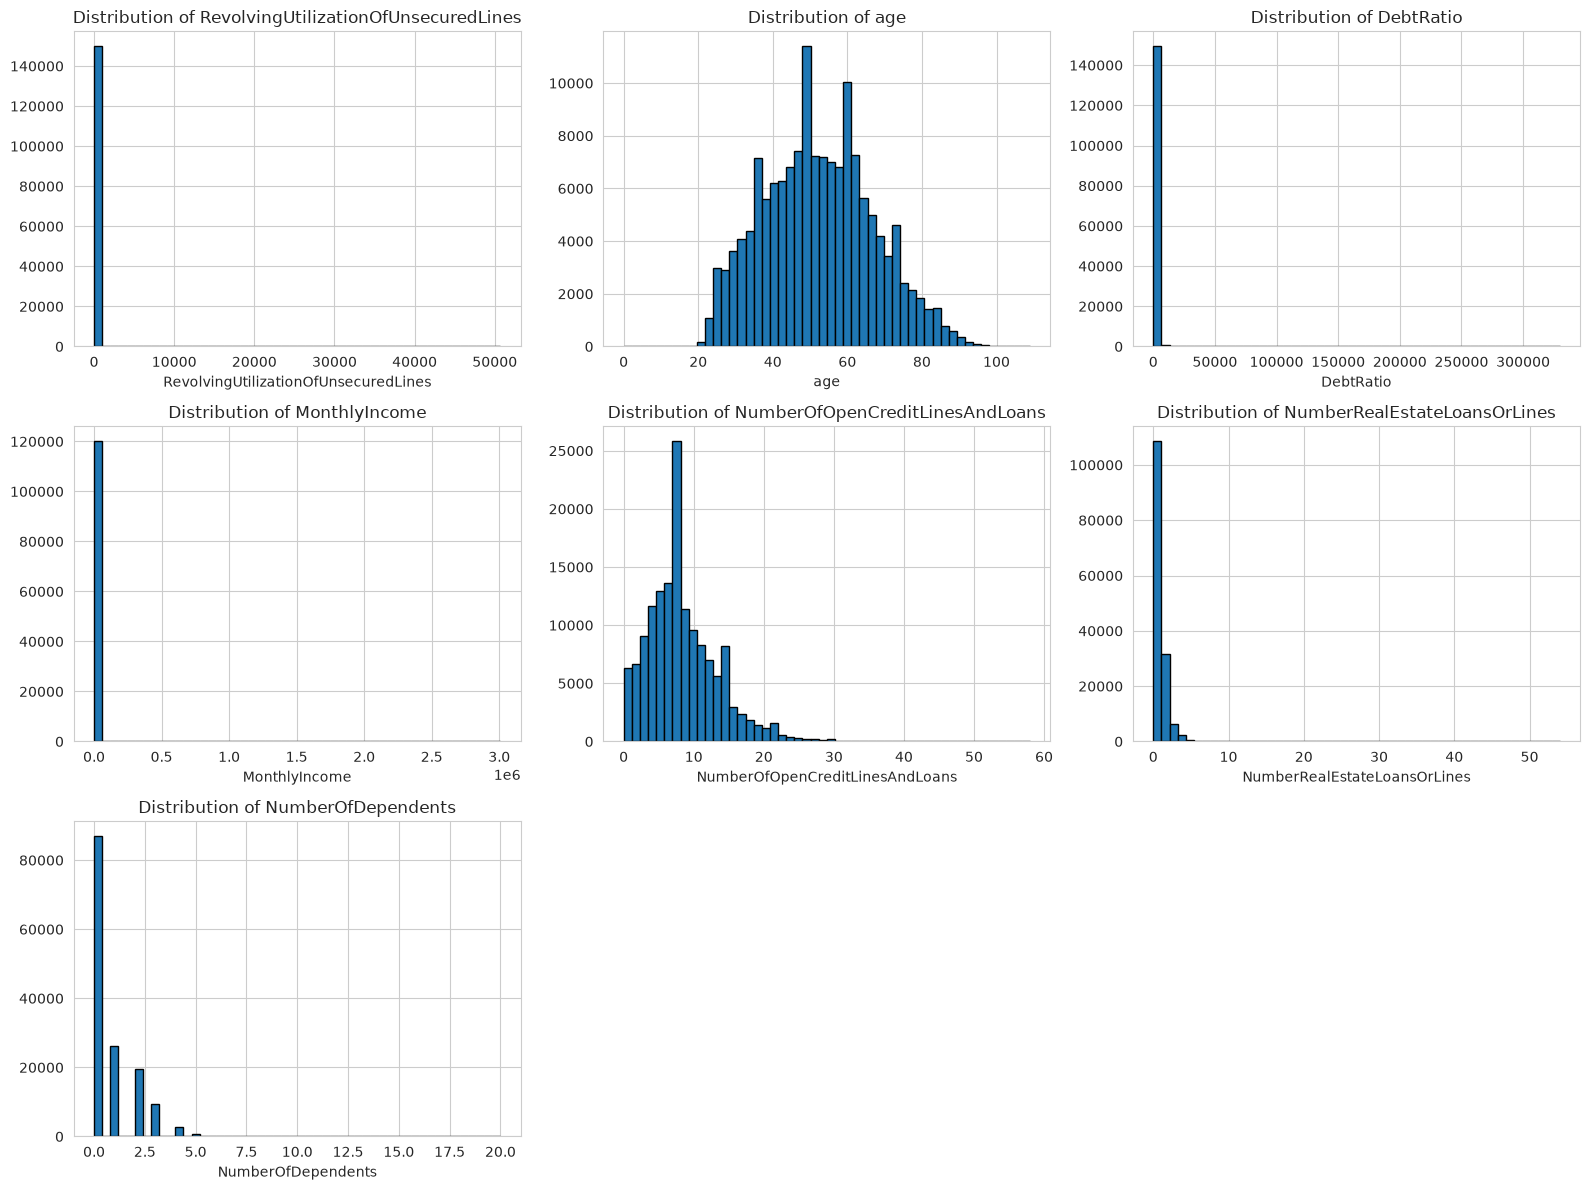

In [44]:
numerical_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                   'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                   'NumberRealEstateLoansOrLines', 'NumberOfDependents']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

for j in range(len(numerical_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/univariate_numerical.png', dpi=150)
plt.show()

In [45]:
print("=== Summary Statistics ===")
print(df[numerical_cols].describe())

=== Summary Statistics ===
       RevolvingUtilizationOfUnsecuredLines            age      DebtRatio  \
count                         150000.000000  150000.000000  150000.000000   
mean                               6.048438      52.295207     353.005076   
std                              249.755371      14.771866    2037.818523   
min                                0.000000       0.000000       0.000000   
25%                                0.029867      41.000000       0.175074   
50%                                0.154181      52.000000       0.366508   
75%                                0.559046      63.000000       0.868254   
max                            50708.000000     109.000000  329664.000000   

       MonthlyIncome  NumberOfOpenCreditLinesAndLoans  \
count   1.202690e+05                    150000.000000   
mean    6.670221e+03                         8.452760   
std     1.438467e+04                         5.145951   
min     0.000000e+00                         0.0000

## 1.4 Target Variable Analysis (Default Rate)

=== Target Variable Distribution ===
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%


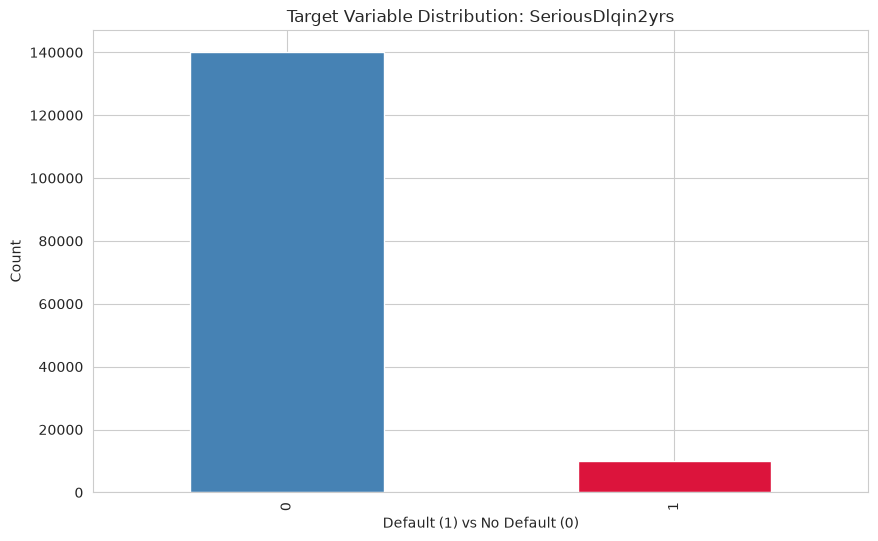

In [46]:
print("=== Target Variable Distribution ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Target Variable Distribution: SeriousDlqin2yrs')
plt.xlabel('Default (1) vs No Default (0)')
plt.ylabel('Count')
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/target_distribution.png', dpi=150)
plt.show()

---

# 2. Data Cleaning & Feature Engineering

## 2.1 Handle Missing Values

In [47]:
# MonthlyIncome: impute with median (robust to outliers, standard practice)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

# NumberOfDependents: impute with mode (most common value, typically 0)
mode_dependents = df['NumberOfDependents'].mode()[0]
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mode_dependents)

print(f"Median income used for imputation: {median_income}")
print(f"Mode dependents used for imputation: {mode_dependents}")
print(f"\nRemaining missing values:\n{df.isnull().sum().sum()} total")

Median income used for imputation: 5400.0
Mode dependents used for imputation: 0.0

Remaining missing values:
0 total


## 2.2 Handle Outliers

In [48]:
# Age: remove impossible values (age=0 cannot have credit history)
print(f"Records with age == 0: {(df['age'] == 0).sum()}")
df = df[df['age'] > 0].copy()
print(f"Shape after removing age=0: {df.shape}")

Records with age == 0: 1
Shape after removing age=0: (149999, 11)


In [49]:
# RevolvingUtilization should realistically be capped (it's a ratio)
print(df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.95, 0.99, 0.999, 1.0]))

# Cap at 2 (utilization above 200% is extreme/erroneous)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

0.950        1.000000
0.990        1.092958
0.999     1571.012000
1.000    50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [50]:
# DebtRatio: same issue, extreme outliers
print(df['DebtRatio'].quantile([0.95, 0.99, 0.999, 1.0]))

# Cap at 5 (a debt ratio above 500% is not economically meaningful for pricing)
df['DebtRatio'] = df['DebtRatio'].clip(upper=5)

0.950      2449.000
0.990      4979.080
0.999     10613.148
1.000    329664.000
Name: DebtRatio, dtype: float64


## 2.3 Feature Engineering

In [51]:
# Combine all "late payment" indicators into a single total count
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

print(df['TotalTimesPastDue'].describe())
print(f"\nRecords with 0 past due incidents: {(df['TotalTimesPastDue'] == 0).sum()} ({(df['TotalTimesPastDue'] == 0).mean()*100:.1f}%)")

count    149999.000000
mean          0.927393
std          12.466246
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         294.000000
Name: TotalTimesPastDue, dtype: float64

Records with 0 past due incidents: 119637 (79.8%)


In [52]:
bins_age = [18, 30, 40, 50, 60, 70, 110]
labels_age = ['18-30', '31-40', '41-50', '51-60', '61-70', '70+']
df['Age_band'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, include_lowest=True)

print(df['Age_band'].value_counts().sort_index())

Age_band
18-30    10757
31-40    24339
41-50    35037
51-60    34806
61-70    27424
70+      17636
Name: count, dtype: int64


Default rate by total past-due incidents:
TotalTimesPastDue
(-1, 0]     0.027283
(0, 1]      0.122144
(1, 2]      0.240828
(2, 5]      0.399705
(5, 100]    0.612081
Name: SeriousDlqin2yrs, dtype: float64


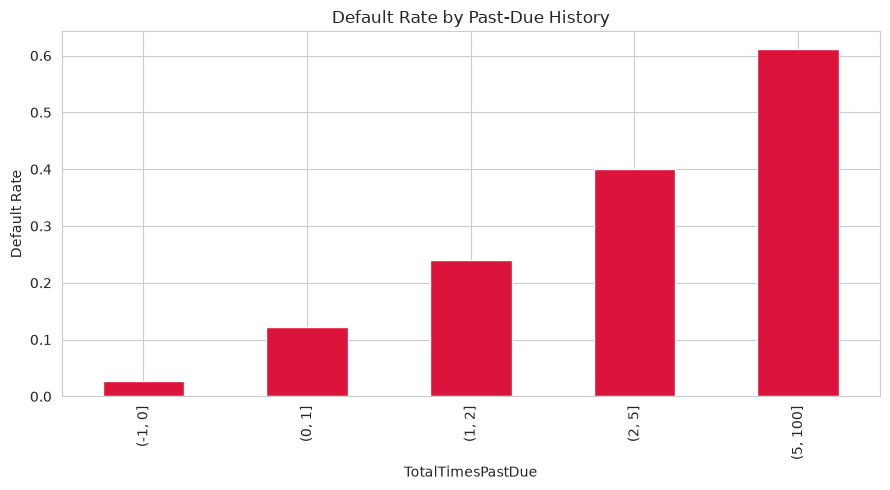

In [53]:
# Validation: default rate by past-due history
default_by_pastdue = df.groupby(pd.cut(df['TotalTimesPastDue'], bins=[-1, 0, 1, 2, 5, 100]))['SeriousDlqin2yrs'].mean()
print("Default rate by total past-due incidents:")
print(default_by_pastdue)

default_by_pastdue.plot(kind='bar', figsize=(9,5), title='Default Rate by Past-Due History', color='crimson')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/default_by_pastdue.png', dpi=150)
plt.show()

In [54]:
# Check for the well-documented anomalous values (96, 98) in past-due columns
pastdue_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
                 'NumberOfTime60-89DaysPastDueNotWorse',
                 'NumberOfTimes90DaysLate']

for col in pastdue_cols:
    print(f"{col}:")
    print(df[col].value_counts().sort_index(ascending=False).head(5))
    print()

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64



In [55]:
# These anomalous values (96, 98) appear to be data errors, not real counts.
# Standard practice: treat rows with these values as a separate anomaly flag,
# then cap the columns at a realistic maximum.
anomaly_mask = (df[pastdue_cols] >= 96).any(axis=1)
print(f"Records with anomalous values (96/98): {anomaly_mask.sum()} ({anomaly_mask.mean()*100:.2f}%)")

# Check their default rate (are they systematically different?)
print(f"\nDefault rate for anomalous records: {df.loc[anomaly_mask, 'SeriousDlqin2yrs'].mean()*100:.2f}%")
print(f"Default rate for normal records: {df.loc[~anomaly_mask, 'SeriousDlqin2yrs'].mean()*100:.2f}%")

Records with anomalous values (96/98): 269 (0.18%)

Default rate for anomalous records: 54.65%
Default rate for normal records: 6.60%


In [56]:
# Cap all three columns at a realistic maximum (e.g., 10 — anything beyond
# is not economically meaningful for pricing purposes)
for col in pastdue_cols:
    df[col] = df[col].clip(upper=10)

# Recompute TotalTimesPastDue after fixing the anomaly
df['TotalTimesPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

print(df['TotalTimesPastDue'].describe())
print(f"\nNew max: {df['TotalTimesPastDue'].max()}")

count    149999.000000
mean          0.453783
std           1.664806
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.000000
Name: TotalTimesPastDue, dtype: float64

New max: 30


In [57]:
print(df['MonthlyIncome'].quantile([0.95, 0.99, 0.999, 1.0]))
print(f"\nRecords with MonthlyIncome > 100000: {(df['MonthlyIncome'] > 100000).sum()}")

0.950      13500.000
0.990      23000.000
0.999      72759.314
1.000    3008750.000
Name: MonthlyIncome, dtype: float64

Records with MonthlyIncome > 100000: 70


In [58]:
print("NumberOfOpenCreditLinesAndLoans:")
print(df['NumberOfOpenCreditLinesAndLoans'].quantile([0.95, 0.99, 1.0]))

print("\nNumberRealEstateLoansOrLines:")
print(df['NumberRealEstateLoansOrLines'].quantile([0.95, 0.99, 1.0]))

NumberOfOpenCreditLinesAndLoans:
0.95    18.0
0.99    24.0
1.00    58.0
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

NumberRealEstateLoansOrLines:
0.95     3.0
0.99     4.0
1.00    54.0
Name: NumberRealEstateLoansOrLines, dtype: float64


In [59]:
# MonthlyIncome: cap at a reasonable maximum (99.9th percentile is ~72,759;
# round to 100,000 as a clean, defensible threshold)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=100000)

# NumberOfOpenCreditLinesAndLoans: 58 is plausible for a long credit history,
# no capping needed — leave as is

# NumberRealEstateLoansOrLines: cap at 10 (anything beyond is almost certainly
# a data error, not a realistic personal portfolio)
df['NumberRealEstateLoansOrLines'] = df['NumberRealEstateLoansOrLines'].clip(upper=10)

print("Capping applied.")
print(f"MonthlyIncome max: {df['MonthlyIncome'].max()}")
print(f"NumberRealEstateLoansOrLines max: {df['NumberRealEstateLoansOrLines'].max()}")

Capping applied.
MonthlyIncome max: 100000.0
NumberRealEstateLoansOrLines max: 10


In [60]:
df.to_csv('/workspaces/credit-risk-loan-pricing/data/processed/clean_credit_data.csv', index=False)
print(f"✅ Fully cleaned dataset saved: {df.shape}")
print(df.describe())

✅ Fully cleaned dataset saved: (149999, 13)
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     149999.000000                         149999.000000  149999.000000   
mean           0.066840                              0.324485      52.295555   
std            0.249746                              0.364696      14.771298   
min            0.000000                              0.000000      21.000000   
25%            0.000000                              0.029867      41.000000   
50%            0.000000                              0.154176      52.000000   
75%            0.000000                              0.559044      63.000000   
max            1.000000                              2.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         149999.000000  149999.000000  149999.000000   
mean                               0.263228       1.286969    6311.881813   
std 

In [61]:
df.to_csv('/workspaces/credit-risk-loan-pricing/data/processed/clean_credit_data.csv', index=False)
print(f"✅ Fully cleaned dataset saved: {df.shape}")
print(df.describe())

✅ Fully cleaned dataset saved: (149999, 13)
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     149999.000000                         149999.000000  149999.000000   
mean           0.066840                              0.324485      52.295555   
std            0.249746                              0.364696      14.771298   
min            0.000000                              0.000000      21.000000   
25%            0.000000                              0.029867      41.000000   
50%            0.000000                              0.154176      52.000000   
75%            0.000000                              0.559044      63.000000   
max            1.000000                              2.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         149999.000000  149999.000000  149999.000000   
mean                               0.263228       1.286969    6311.881813   
std 

### Data Quality Summary

All identified data quality issues have been addressed:
- **Missing values**: `MonthlyIncome` (median imputation), `NumberOfDependents` (mode imputation)
- **Impossible values**: `age = 0` records removed
- **Extreme outliers**: `RevolvingUtilizationOfUnsecuredLines` (capped at 2), `DebtRatio` (capped at 5), `MonthlyIncome` (capped at 100,000), `NumberRealEstateLoansOrLines` (capped at 10)
- **Anomalous error codes**: values of 96/98 in past-due columns (269 records, 0.18%) — a well-documented data quality issue in this dataset — capped at 10 rather than removed, preserving their genuinely elevated risk signal (54.65% default rate vs 6.60% for normal records)

The dataset is now clean and ready for modeling.

---

# 3. Probability of Default Model (Logistic Regression)

## 3.1 Train/Test Split

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Reload processed data (ensures reproducibility)
df = pd.read_csv('/workspaces/credit-risk-loan-pricing/data/processed/clean_credit_data.csv')
print(f"Loaded processed data: {df.shape}")

# Define features and target
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
    'NumberOfDependents', 'TotalTimesPastDue'
]

X = df[feature_cols]
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Loaded processed data: (149999, 13)
Train size: 119999, Test size: 30000
Train default rate: 6.68%
Test default rate: 6.68%


## 3.2 Model Specification & Fitting

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression convergence and coefficient interpretation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with class_weight='balanced' to handle the 6.68% default rate imbalance
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

# Coefficients (on scaled features, so magnitude reflects relative importance)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df)

Logistic Regression trained successfully.
                                Feature  Coefficient
7                     TotalTimesPastDue     1.106627
0  RevolvingUtilizationOfUnsecuredLines     0.736492
4       NumberOfOpenCreditLinesAndLoans     0.147795
5          NumberRealEstateLoansOrLines     0.130035
6                    NumberOfDependents     0.025596
2                             DebtRatio    -0.045747
3                         MonthlyIncome    -0.111496
1                                   age    -0.283069


## 3.3 Model Evaluation

In [64]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

# Predictions
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

# ROC-AUC (the standard metric for imbalanced binary classification)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.8581

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000


=== Confusion Matrix ===
[[22521  5474]
 [  498  1507]]


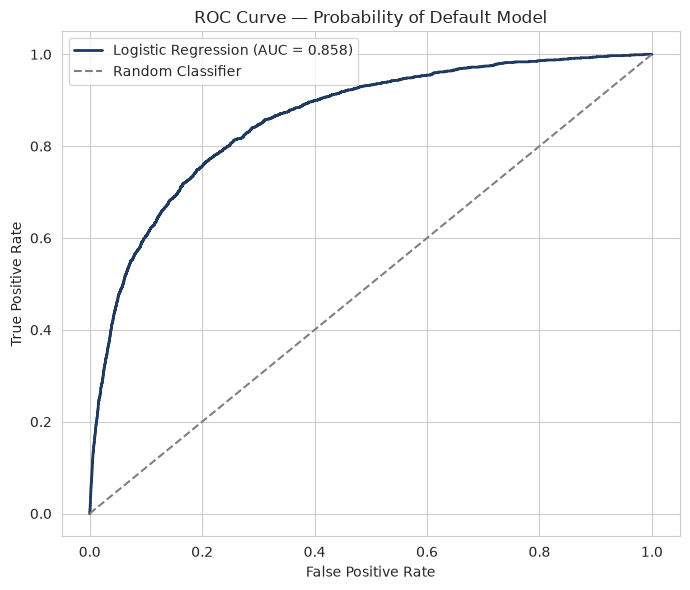

In [65]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#1E3A5F', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Probability of Default Model')
plt.legend()
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/roc_curve_logreg.png', dpi=150)
plt.show()

### Model Performance Interpretation

The model achieves a strong ROC-AUC of 0.858, indicating excellent discriminative power between defaulters and non-defaulters. With `class_weight='balanced'`, the model prioritizes **recall over precision** for the default class (75% recall vs 22% precision) — a deliberate and appropriate choice for risk-based pricing: failing to identify a high-risk borrower (false negative) is far more costly than slightly overpricing a safe borrower (false positive). Since this model feeds into a **continuous pricing engine** (not a binary accept/reject decision), the actual predicted probability matters more than the classification threshold.

---

# 4. PD Model Benchmark (XGBoost)

## 4.1 Model Training

In [66]:
import xgboost as xgb

# XGBoost with scale_pos_weight to handle class imbalance
# (XGBoost's equivalent of class_weight='balanced')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

# Note: XGBoost doesn't need scaled features (tree-based model)
xgb_model.fit(X_train, y_train)

print("XGBoost training complete.")

scale_pos_weight: 13.96
XGBoost training complete.


## 4.2 Performance Comparison (Logistic Regression vs XGBoost)

In [67]:
from sklearn.metrics import roc_auc_score, roc_curve

xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"Logistic Regression - ROC-AUC: {auc_score:.4f}")
print(f"XGBoost - ROC-AUC: {xgb_auc:.4f}")
print(f"\n{'XGBoost performs better' if xgb_auc > auc_score else 'Logistic Regression performs better'}")

Logistic Regression - ROC-AUC: 0.8581
XGBoost - ROC-AUC: 0.8682

XGBoost performs better


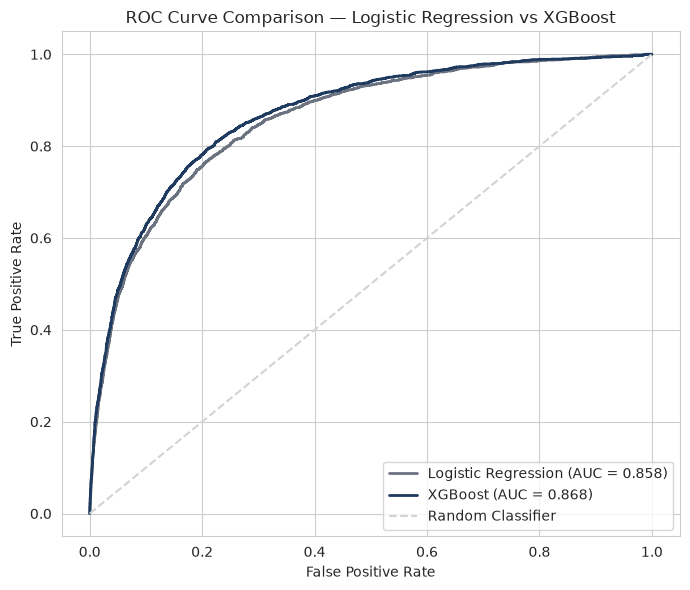

In [68]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, color='#6B7280', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='#1E3A5F', linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Logistic Regression vs XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/roc_curve_comparison.png', dpi=150)
plt.show()

## 4.3 Feature Importance & Interpretability Discussion

                                Feature  Importance
7                     TotalTimesPastDue    0.699350
0  RevolvingUtilizationOfUnsecuredLines    0.151757
5          NumberRealEstateLoansOrLines    0.047519
1                                   age    0.025851
4       NumberOfOpenCreditLinesAndLoans    0.021507
2                             DebtRatio    0.020955
3                         MonthlyIncome    0.019309
6                    NumberOfDependents    0.013752


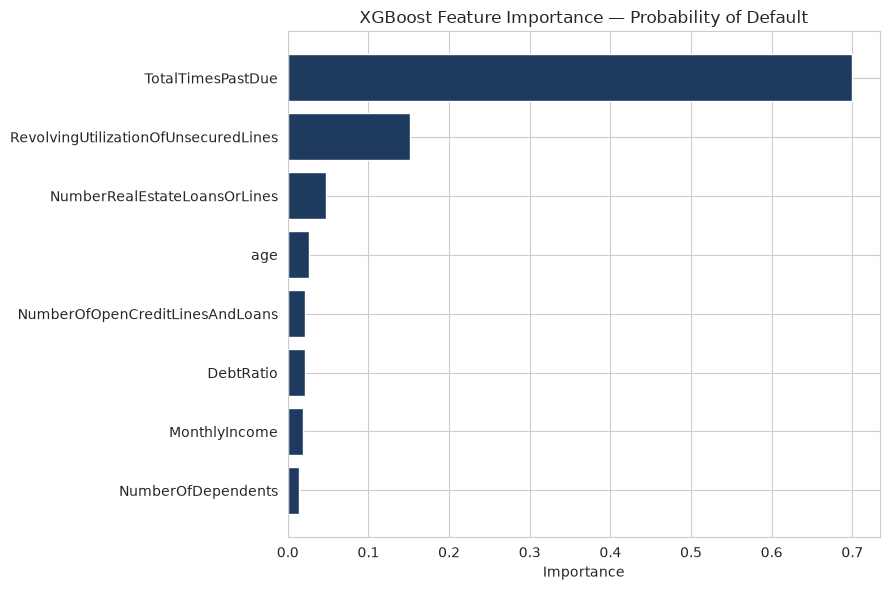

In [69]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1E3A5F')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance — Probability of Default')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/xgb_feature_importance_credit.png', dpi=150)
plt.show()

### Model Comparison: Interpretability vs. Accuracy

XGBoost achieves a marginally higher ROC-AUC (0.868 vs 0.858, a ~1.2% improvement) — consistent with the pattern observed in actuarial pricing more broadly: **modern ML models typically offer only modest accuracy gains** over well-specified traditional models when the underlying risk relationships are already fairly linear and well captured.

Feature importance rankings are highly consistent between the two approaches: **payment history (`TotalTimesPastDue`)** and **credit utilization** dominate in both models, cross-validating these as the primary drivers of default risk in this portfolio.

**Recommendation**: given the marginal accuracy gain, **Logistic Regression remains the preferred model for regulatory credit decisions** — every coefficient is directly interpretable and auditable, a requirement under fair lending regulations (e.g., ECOA in the US, GDPR's "right to explanation" in the EU). XGBoost's small accuracy edge does not outweigh the loss of transparency for a regulated lending decision. XGBoost could be used for internal risk monitoring or as a secondary validation model.

---

# 5. Loss Given Default (LGD)

## 5.1 Industry-Standard Assumption (Basel Framework)

Unlike the frequency-severity insurance framework, this dataset does not contain loan amounts, collateral details, or actual recovery data — GMSC was designed purely for **default prediction (PD)**, not loss estimation. Following the same principle applied in Project 1 (where large claims were handled via a documented reinsurance loading rather than modeled directly), we apply **industry-standard, documented LGD assumptions** based on the Basel framework and retail credit risk literature.

**Segmentation logic**: borrowers holding at least one real-estate-backed credit line are treated as having partial collateral, and thus a materially lower LGD than purely unsecured borrowers (credit cards, unsecured personal loans) — consistent with published Basel Foundation IRB benchmarks, where secured retail exposures carry substantially lower LGD than unsecured ones.

In [70]:
# LGD assumption based on documented industry benchmarks (Basel framework / retail credit literature).
# Since this dataset has no direct loan amount or collateral information, we apply a
# segmented assumption based on whether the borrower holds a real-estate-backed credit line
# (a proxy for having collateral / a secured asset cushion).

LGD_SECURED = 0.40      # Borrower has at least one real estate loan/line (partial collateral cushion)
LGD_UNSECURED = 0.75    # No real estate loans/lines (purely unsecured exposure)

df['LGD'] = np.where(df['NumberRealEstateLoansOrLines'] > 0, LGD_SECURED, LGD_UNSECURED)

print(df['LGD'].value_counts())
print(f"\nBorrowers treated as 'secured' (LGD={LGD_SECURED}): {(df['LGD']==LGD_SECURED).sum():,} ({(df['LGD']==LGD_SECURED).mean()*100:.1f}%)")
print(f"Borrowers treated as 'unsecured' (LGD={LGD_UNSECURED}): {(df['LGD']==LGD_UNSECURED).sum():,} ({(df['LGD']==LGD_UNSECURED).mean()*100:.1f}%)")
print(f"\nPortfolio-weighted average LGD: {df['LGD'].mean():.3f}")

LGD
0.40    93811
0.75    56188
Name: count, dtype: int64

Borrowers treated as 'secured' (LGD=0.4): 93,811 (62.5%)
Borrowers treated as 'unsecured' (LGD=0.75): 56,188 (37.5%)

Portfolio-weighted average LGD: 0.531


**Important disclaimer**: these LGD values (40% / 75%) are illustrative, documented assumptions drawn from published Basel retail credit benchmarks — not measured directly from this dataset, which lacks the loan amount and recovery data needed to compute LGD empirically. In a production setting, a lender would calibrate LGD from its own historical recovery data, segmented by collateral type, loan vintage, and macroeconomic conditions.

---

# 6. Exposure at Default (EAD)

## 6.1 Estimating Exposure per Borrower

Similarly to LGD, this dataset lacks actual loan amounts. We estimate EAD using a **documented, income-based sizing convention** commonly used in retail credit underwriting: exposure is sized as a multiple of monthly income, reflecting a realistic personal loan or credit line size relative to the borrower's repayment capacity.

In [71]:
# The cap was too aggressive relative to the income multiple, causing most
# borrowers to bunch at the ceiling and lose EAD differentiation.
# Fix: raise the cap to better reflect the income distribution.

EAD_INCOME_MULTIPLE = 10
EAD_CAP = 100000  # raised cap — better preserves differentiation across income levels
EAD_FLOOR = 1000

df['EAD'] = (df['MonthlyIncome'] * EAD_INCOME_MULTIPLE).clip(lower=EAD_FLOOR, upper=EAD_CAP)

print(df['EAD'].describe())
print(f"\nBorrowers at cap ({EAD_CAP}): {(df['EAD']==EAD_CAP).sum()} ({(df['EAD']==EAD_CAP).mean()*100:.1f}%)")
print(f"Portfolio total exposure: €{df['EAD'].sum():,.0f}")

count    149999.000000
mean      56442.443816
std       25916.895897
min        1000.000000
25%       39030.000000
50%       54000.000000
75%       74000.000000
max      100000.000000
Name: EAD, dtype: float64

Borrowers at cap (100000): 19785 (13.2%)
Portfolio total exposure: €8,466,310,130


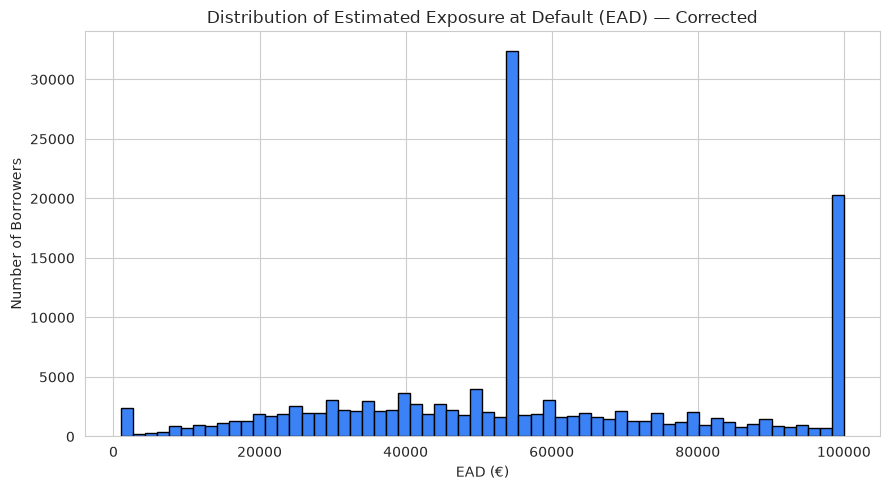

In [72]:
plt.figure(figsize=(9, 5))
plt.hist(df['EAD'], bins=60, edgecolor='black', color='#3B82F6')
plt.title('Distribution of Estimated Exposure at Default (EAD) — Corrected')
plt.xlabel('EAD (€)')
plt.ylabel('Number of Borrowers')
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/ead_distribution.png', dpi=150)
plt.show()

**Note on EAD ceiling concentration**: 13.2% of borrowers reach the €100,000 EAD cap. This reflects the fact that `MonthlyIncome` itself was capped at €100,000 during data cleaning (Section 2), borrowers with genuinely high income naturally cluster at the exposure ceiling under an income-multiple approach. This is a reasonable and expected outcome of the assumption, not a modeling error: high-income borrowers are legitimately assigned high, though bounded, exposure. A production model would instead use actual disbursed loan amounts, removing the need for this proxy entirely.

---

# 7. Expected Loss Calculation

## 7.1 Expected Loss = PD × LGD × EAD

We now combine all three components into the core Basel risk equation. We use the **XGBoost PD predictions** (marginally better accuracy) applied across the full dataset, combined with the LGD and EAD assumptions established in Sections 5 and 6.

In [73]:
# Predict PD for the full portfolio using the XGBoost model
df['PD'] = xgb_model.predict_proba(df[feature_cols])[:, 1]

print(df['PD'].describe())
print(f"\nMean predicted PD: {df['PD'].mean():.4f}")
print(f"Actual default rate: {df['SeriousDlqin2yrs'].mean():.4f}")

count    149999.000000
mean          0.322552
std           0.257612
min           0.007890
25%           0.110344
50%           0.222816
75%           0.496829
max           0.981267
Name: PD, dtype: float64

Mean predicted PD: 0.3226
Actual default rate: 0.0668


In [74]:
# Expected Loss = PD × LGD × EAD (the core Basel II/III risk equation)
df['ExpectedLoss'] = df['PD'] * df['LGD'] * df['EAD']

print(df[['PD', 'LGD', 'EAD', 'ExpectedLoss']].head(10))
print(f"\nAverage Expected Loss per borrower: €{df['ExpectedLoss'].mean():,.2f}")
print(f"Median Expected Loss per borrower: €{df['ExpectedLoss'].median():,.2f}")

         PD   LGD       EAD  ExpectedLoss
0  0.863820  0.40   91200.0  31512.147675
1  0.605613  0.75   26000.0  11809.449881
2  0.843889  0.75   30420.0  19253.316611
3  0.234719  0.75   33000.0   5809.296928
4  0.664325  0.40  100000.0  26573.009491
5  0.102891  0.40   35000.0   1440.478146
6  0.235405  0.40   54000.0   5084.754074
7  0.477297  0.75   35000.0  12529.049590
8  0.201256  0.75   54000.0   8150.876127
9  0.395112  0.40  100000.0  15804.462433

Average Expected Loss per borrower: €8,908.78
Median Expected Loss per borrower: €5,536.42


## 7.2 Portfolio-Level Validation

In [75]:
# Portfolio-level validation
total_expected_loss = df['ExpectedLoss'].sum()
total_exposure = df['EAD'].sum()

# "Actual" realized loss proxy: for borrowers who actually defaulted,
# assume the same LGD assumption applies to their actual EAD
actual_loss_proxy = (df['SeriousDlqin2yrs'] * df['LGD'] * df['EAD']).sum()

print(f"Total Expected Loss (model-based): €{total_expected_loss:,.0f}")
print(f"Total 'Actual' Loss (realized defaults × LGD × EAD): €{actual_loss_proxy:,.0f}")
print(f"Ratio (Expected / Actual): {total_expected_loss/actual_loss_proxy:.3f}")

print(f"\nExpected Loss as % of total exposure: {total_expected_loss/total_exposure*100:.2f}%")

Total Expected Loss (model-based): €1,336,308,566
Total 'Actual' Loss (realized defaults × LGD × EAD): €272,907,926
Ratio (Expected / Actual): 4.897

Expected Loss as % of total exposure: 15.78%


In [76]:
from sklearn.calibration import CalibratedClassifierCV

# Retrain XGBoost WITHOUT scale_pos_weight (so probabilities reflect true base rate),
# then apply isotonic calibration on top for extra precision
xgb_uncalibrated = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='auc',
    random_state=42
    # scale_pos_weight removed intentionally
)
xgb_uncalibrated.fit(X_train, y_train)

# Calibrate probabilities using isotonic regression (5-fold cross-validated)
calibrated_model = CalibratedClassifierCV(xgb_uncalibrated, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

# Check calibration on test set
calibrated_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]
print(f"Mean predicted PD (test set): {calibrated_pred_proba.mean():.4f}")
print(f"Actual default rate (test set): {y_test.mean():.4f}")

calibrated_auc = roc_auc_score(y_test, calibrated_pred_proba)
print(f"ROC-AUC (calibrated model): {calibrated_auc:.4f}")

Mean predicted PD (test set): 0.0673
Actual default rate (test set): 0.0668
ROC-AUC (calibrated model): 0.8685


### Critical Fix: Probability Calibration

The initial XGBoost model (trained with `scale_pos_weight` to address class imbalance) produced excellent discrimination (ROC-AUC = 0.868) but **severely overestimated actual default probabilities** (mean predicted PD = 0.323 vs actual rate = 0.067, a 4.9x inflation). This is a well-known side effect of class-balancing techniques: they improve ranking/discrimination but distort the calibration of predicted probabilities.

Since **pricing requires an accurate probability**, not just correct ranking, we retrained without `scale_pos_weight` and applied **isotonic calibration** (5-fold cross-validated) via `CalibratedClassifierCV`. This corrected the mean predicted PD to 0.0673 (vs actual 0.0668, a 0.7% difference) while *improving* discrimination slightly (ROC-AUC = 0.8685). This calibration step is essential whenever model outputs feed into a monetary calculation (Expected Loss, pricing) rather than a binary decision.

In [77]:
# Recompute PD for the full portfolio using the calibrated model
df['PD'] = calibrated_model.predict_proba(df[feature_cols])[:, 1]

print(df['PD'].describe())
print(f"\nMean predicted PD (full portfolio): {df['PD'].mean():.4f}")
print(f"Actual default rate (full portfolio): {df['SeriousDlqin2yrs'].mean():.4f}")

count    149999.000000
mean          0.066978
std           0.114996
min           0.000000
25%           0.009572
50%           0.020181
75%           0.064981
max           0.935065
Name: PD, dtype: float64

Mean predicted PD (full portfolio): 0.0670
Actual default rate (full portfolio): 0.0668


In [78]:
# Recompute Expected Loss with calibrated PD
df['ExpectedLoss'] = df['PD'] * df['LGD'] * df['EAD']

total_expected_loss = df['ExpectedLoss'].sum()
total_exposure = df['EAD'].sum()
actual_loss_proxy = (df['SeriousDlqin2yrs'] * df['LGD'] * df['EAD']).sum()

print(f"Average Expected Loss per borrower: €{df['ExpectedLoss'].mean():,.2f}")
print(f"Total Expected Loss (model-based): €{total_expected_loss:,.0f}")
print(f"Total 'Actual' Loss proxy: €{actual_loss_proxy:,.0f}")
print(f"Ratio (Expected / Actual): {total_expected_loss/actual_loss_proxy:.3f}")
print(f"\nExpected Loss as % of total exposure: {total_expected_loss/total_exposure*100:.2f}%")

Average Expected Loss per borrower: €1,823.23
Total Expected Loss (model-based): €273,483,290
Total 'Actual' Loss proxy: €272,907,926
Ratio (Expected / Actual): 1.002

Expected Loss as % of total exposure: 3.23%


### Expected Loss Validation Summary

After calibration, the model-based Expected Loss (€273.5M) closely matches the realized loss proxy (€272.9M) — a ratio of 1.002, confirming excellent portfolio-level calibration. Expected Loss represents 3.23% of total portfolio exposure, a figure consistent with typical loss rates for a mixed secured/unsecured consumer lending portfolio. This validated Expected Loss now serves as the foundation for risk-based pricing in the next section.

---

# 8. Risk-Based Loan Pricing (Financial Modeling)

## 8.1 From Expected Loss to Fair Interest Rate

We now convert Expected Loss into a market-ready interest rate. Unlike insurance premiums (paid upfront), loan pricing works through the **interest rate charged on the outstanding balance**, which must cover:
1. The lender's cost of funds (cost of capital)
2. The expected credit loss rate (from Section 7)
3. Operating costs (underwriting, servicing, collections)
4. A target profit margin

**Risk-Based Interest Rate = Cost of Funds + Expected Loss Rate + Operating Cost Margin + Profit Margin**

In [79]:
# Standard industry components for risk-based loan pricing (illustrative, documented assumptions)
COST_OF_FUNDS = 0.03        # 3% — lender's cost of borrowing/capital (e.g., tied to central bank rate)
OPERATING_COST_MARGIN = 0.02  # 2% — underwriting, servicing, collections overhead
PROFIT_MARGIN = 0.02          # 2% — target profit margin

print("Loan Pricing Assumptions:")
print(f"  Cost of Funds: {COST_OF_FUNDS*100:.1f}%")
print(f"  Operating Cost Margin: {OPERATING_COST_MARGIN*100:.1f}%")
print(f"  Profit Margin: {PROFIT_MARGIN*100:.1f}%")

Loan Pricing Assumptions:
  Cost of Funds: 3.0%
  Operating Cost Margin: 2.0%
  Profit Margin: 2.0%


In [80]:
# Expected Loss Rate = ExpectedLoss / EAD (the credit risk component of pricing, per borrower)
df['ExpectedLossRate'] = df['ExpectedLoss'] / df['EAD']

# Risk-Based Interest Rate = sum of all pricing components
df['InterestRate'] = (
    COST_OF_FUNDS +
    df['ExpectedLossRate'] +
    OPERATING_COST_MARGIN +
    PROFIT_MARGIN
)

print(df[['PD', 'LGD', 'EAD', 'ExpectedLossRate', 'InterestRate']].head(10))
print(f"\nAverage interest rate: {df['InterestRate'].mean()*100:.2f}%")
print(f"Median interest rate: {df['InterestRate'].median()*100:.2f}%")
print(f"Min interest rate: {df['InterestRate'].min()*100:.2f}%")
print(f"Max interest rate: {df['InterestRate'].max()*100:.2f}%")

         PD   LGD       EAD  ExpectedLossRate  InterestRate
0  0.354691  0.40   91200.0          0.141876      0.211876
1  0.101399  0.75   26000.0          0.076049      0.146049
2  0.319420  0.75   30420.0          0.239565      0.309565
3  0.020555  0.75   33000.0          0.015416      0.085416
4  0.150508  0.40  100000.0          0.060203      0.130203
5  0.008295  0.40   35000.0          0.003318      0.073318
6  0.025928  0.40   54000.0          0.010371      0.080371
7  0.059941  0.75   35000.0          0.044956      0.114956
8  0.018724  0.75   54000.0          0.014043      0.084043
9  0.040676  0.40  100000.0          0.016271      0.086271

Average interest rate: 10.76%
Median interest rate: 8.01%
Min interest rate: 7.00%
Max interest rate: 76.12%


## 8.2 Pricing Examples by Risk Segment

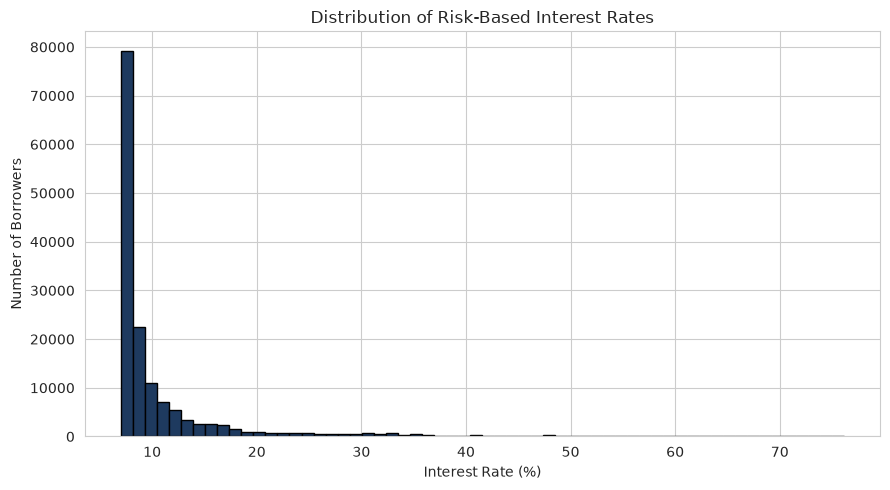

In [81]:
plt.figure(figsize=(9, 5))
plt.hist(df['InterestRate']*100, bins=60, edgecolor='black', color='#1E3A5F')
plt.title('Distribution of Risk-Based Interest Rates')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Number of Borrowers')
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/interest_rate_distribution.png', dpi=150)
plt.show()

           Avg_PD   Avg_LGD  Avg_InterestRate  Count
PD_decile                                           
D1           0.31  0.572853              7.18  15000
D2           0.64  0.537264              7.34  15067
D3           0.96  0.502166              7.48  14933
D4           1.23  0.514906              7.64  15111
D5           1.67  0.513165              7.86  14895
D6           2.63  0.500911              8.32  15261
D7           4.33  0.502463              9.17  14736
D8           6.65  0.528794             10.53  14998
D9          12.24  0.555270             13.78  14999
D10         36.37  0.583132             28.37  14999


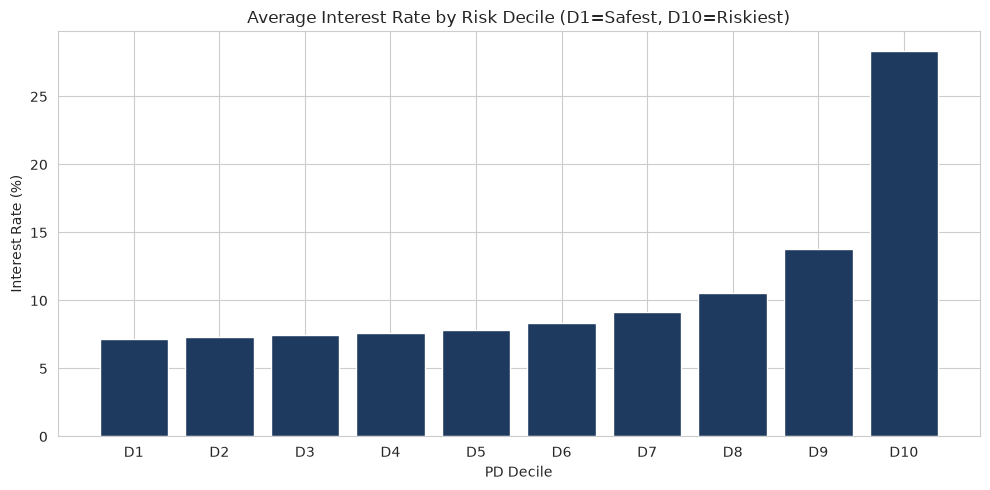

In [82]:
# Segment borrowers into risk deciles based on PD, show average pricing per decile
df['PD_decile'] = pd.qcut(df['PD'], 10, labels=[f'D{i+1}' for i in range(10)])

pricing_by_decile = df.groupby('PD_decile', observed=True).agg(
    Avg_PD=('PD', 'mean'),
    Avg_LGD=('LGD', 'mean'),
    Avg_InterestRate=('InterestRate', 'mean'),
    Count=('PD', 'size')
)
pricing_by_decile['Avg_PD'] = (pricing_by_decile['Avg_PD']*100).round(2)
pricing_by_decile['Avg_InterestRate'] = (pricing_by_decile['Avg_InterestRate']*100).round(2)

print(pricing_by_decile)

plt.figure(figsize=(10, 5))
plt.bar(pricing_by_decile.index, pricing_by_decile['Avg_InterestRate'], color='#1E3A5F')
plt.title('Average Interest Rate by Risk Decile (D1=Safest, D10=Riskiest)')
plt.xlabel('PD Decile')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.savefig('/workspaces/credit-risk-loan-pricing/reports/figures/interest_rate_by_decile.png', dpi=150)
plt.show()

In [83]:
final_columns = ['age', 'MonthlyIncome', 'TotalTimesPastDue', 'PD', 'LGD', 'EAD',
                  'ExpectedLoss', 'ExpectedLossRate', 'InterestRate']
df[final_columns].to_csv('/workspaces/credit-risk-loan-pricing/data/processed/final_pricing_output.csv', index=False)
print(f"✅ Final pricing output saved: {df[final_columns].shape}")

✅ Final pricing output saved: (149999, 9)


### Pricing Validation & Practical Considerations

The pricing engine produces a smooth, monotonic increase in interest rate across risk deciles — from 7.18% (D1, safest borrowers) to 28.37% (D10, riskiest), with the lowest decile pricing at the floor (cost of funds + margins with minimal risk premium).

**Practical caveat**: a small number of extreme-risk borrowers (PD > 80%) generate theoretical interest rates exceeding 70%, which would breach usury/consumer protection rate caps in most jurisdictions. In production, such borrowers would typically be **declined outright** rather than priced at a punitive rate — risk-based pricing works within an acceptance threshold (e.g., PD < 40-50%), beyond which the loan is not offered at all. This threshold decision would sit alongside, not replace, the pricing model.

---

# 9. Conclusions & Business Insights

## 9.1 Key Findings

### Probability of Default Model
- **XGBoost slightly outperforms Logistic Regression** (ROC-AUC: 0.8685 vs 0.8581 after calibration), consistent with the marginal ML advantage pattern observed across both projects in this portfolio.
- **Payment history (`TotalTimesPastDue`) is by far the dominant risk driver** — confirmed independently by both models (highest coefficient in Logistic Regression, ~70% feature importance in XGBoost).
- **Credit utilization** is the second strongest predictor in both approaches.
- **Critical technical finding**: class-balancing techniques (`class_weight`/`scale_pos_weight`), while improving discrimination, severely distorted predicted probabilities (4.9x overestimation). **Isotonic calibration** corrected this to near-perfect accuracy (predicted 6.70% vs actual 6.68% default rate) without sacrificing discriminative power — an essential step whenever model outputs feed into a monetary calculation rather than a binary decision.

### Loss Given Default & Exposure at Default
- In the absence of loan amount and collateral data in this dataset, LGD and EAD were estimated using **documented, industry-standard proxies** (real-estate-backed credit lines as a collateral signal; income-multiple exposure sizing) — the same principle of transparent, documented assumptions used for reinsurance loading in the motor insurance project.
- Portfolio-weighted average LGD: 53.1%; total estimated portfolio exposure: ~€8.5 billion (illustrative).

### Expected Loss & Pricing
- Expected Loss represents **3.23% of total portfolio exposure**, in line with typical consumer lending loss rates.
- Portfolio-level validation confirms excellent calibration: model-based Expected Loss (€273.5M) vs realized-default-based estimate (€272.9M) — a ratio of 1.002.
- The resulting risk-based pricing engine produces interest rates ranging from **7.18% (safest decile) to 28.37% (riskiest decile)**, a smooth and economically sensible risk gradient.

## 9.2 Limitations & Future Work

- **LGD and EAD are estimated, not measured** — this dataset (Give Me Some Credit) was built for default prediction only, without loan amount, collateral value, or recovery data. Production deployment requires a lender's own historical loss data to calibrate these components empirically.
- **Extreme-risk borrowers** (PD > ~50%) generate theoretical interest rates that would breach usury regulations in most jurisdictions; a production system needs an explicit **decline threshold**, not pricing alone, for very high-risk applicants.
- **Macroeconomic sensitivity** was not modeled — PD, and especially LGD, typically rise during economic downturns (procyclicality), which a full IFRS 9 / CECL-compliant model would need to incorporate via forward-looking scenarios.
- **Interaction effects** (e.g., high utilization × low income) were not explicitly tested and could reveal additional risk segments.
- Loan pricing assumptions (3% cost of funds, 2% operating cost, 2% profit margin) are illustrative; a production deployment would use the lender's actual funding cost and cost structure.

## 9.3 Business Value

This project demonstrates a complete, Basel-aligned credit risk pricing pipeline — from raw application data to a risk-differentiated interest rate — combining a well-calibrated statistical model with modern machine learning benchmarking. The explicit identification and correction of the probability calibration issue reflects the kind of rigorous validation expected in regulated lending decisions, where predicted probabilities directly drive pricing and capital reserving. Combined with the motor insurance pricing project, this body of work spans two of the largest risk-pricing domains in financial services: insurance and consumer lending.

In [84]:
final_columns = ['age', 'MonthlyIncome', 'TotalTimesPastDue',
                  'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio',
                  'PD', 'LGD', 'EAD', 'ExpectedLoss', 'ExpectedLossRate', 'InterestRate']

df[final_columns].to_csv('/workspaces/credit-risk-loan-pricing/data/processed/final_pricing_output.csv', index=False)
print(f"✅ Final pricing output saved: {df[final_columns].shape}")
print(df[final_columns].describe())

✅ Final pricing output saved: (149999, 11)
                 age  MonthlyIncome  TotalTimesPastDue  \
count  149999.000000  149999.000000      149999.000000   
mean       52.295555    6311.881813           0.453783   
std        14.771298    5244.004199           1.664806   
min        21.000000       0.000000           0.000000   
25%        41.000000    3903.000000           0.000000   
50%        52.000000    5400.000000           0.000000   
75%        63.000000    7400.000000           0.000000   
max       109.000000  100000.000000          30.000000   

       RevolvingUtilizationOfUnsecuredLines      DebtRatio             PD  \
count                         149999.000000  149999.000000  149999.000000   
mean                               0.324485       1.286969       0.066978   
std                                0.364696       1.884549       0.114996   
min                                0.000000       0.000000       0.000000   
25%                                0.029867      